In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print(PROJECT_ROOT)
print(DATA_PROCESSED)

c:\Users\karol\Desktop\esp_industrial_ml
c:\Users\karol\Desktop\esp_industrial_ml\data\processed


In [2]:
processed_files = list(DATA_PROCESSED.glob("*.parquet"))

print(processed_files)

df = pd.read_parquet(processed_files[0])

print(df.shape)
df.head()

[WindowsPath('c:/Users/karol/Desktop/esp_industrial_ml/data/processed/dataset_clean.parquet')]
(217781, 77)


,008A00444,008A00936,008A00910,008A00911,008A00720,008A00728,008A02273,008A02274,008A02275,008A00719,008A00727,008A01350,008A01341,008A01343,008A01347,008A01345,008A02118,016A00219,008A00723,016A00396,008A00731,008A01353,008B01474,008B01479,008B01484,008B01489,source_file,008A00741,008A00742,008B05167,008A02270,008A02292,008B05155,008A02267,008A02289,008A02264,008B05146,008B05131,008B05140,008A02276,008A02277,008B05100,008B05103,008A02282,008A02283,008B05173,008A02271,008A02293,008A02268,008A02290,008A02265,008B05150,008B05135,008A02278,008B05106,008A02284,008A02279,008B05109,008A02285,008B05178,008A02272,008A02294,008A02269,008A02291,008A02266,008B05154,008B05139,008A02280,008B05112,008A02286,008A02281,008B05115,008A02287,008B05096,008B05121,008B05126,008B05117
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-30 00:00:00,186.0,32.500000,68282.0,73877.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,11.0,4.9,137.0,13.0,149.0,14.0,146.0,0.0,0.0,0.0,0.0,1.xls,5.1,8.9,1.0,266.0,390.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,212.0,392.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,212.0,388.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:10,186.0,31.700001,68103.0,73804.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,11.0,4.9,137.0,13.0,149.0,13.0,146.0,0.0,0.0,0.0,0.0,1.xls,5.1,9.0,1.0,266.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,211.0,393.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,214.0,388.0,301.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:20,186.0,32.000000,68766.0,73499.0,124.0,126.0,14.0,12.1,11.3,-0.63,-0.55,8.2,1308.0,174.0,44.0,11.0,4.9,136.0,13.0,149.0,13.0,151.0,0.0,0.0,0.0,0.0,1.xls,5.1,9.1,1.0,267.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,86.0,1.0,214.0,391.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,217.0,385.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:30,186.0,31.799999,68103.0,73645.0,124.0,126.0,13.8,11.8,11.2,-0.63,-0.55,8.2,1308.0,174.0,44.0,11.0,4.9,136.0,13.0,149.0,14.0,151.0,0.0,0.0,0.0,0.0,1.xls,5.2,9.0,1.0,266.0,389.0,1.0,294.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,209.0,393.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,214.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:40,186.0,32.400002,68209.0,73645.0,125.0,126.0,14.0,11.9,11.2,-0.63,-0.54,8.2,1313.0,173.0,45.0,9.0,4.9,136.0,13.0,149.0,14.0,150.0,0.0,0.0,0.0,0.0,1.xls,5.2,9.1,1.0,269.0,389.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,207.0,394.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,209.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,87.0,0.0,32.0,1.0,1.0,1.0,1.0


In [3]:
print(type(df.index))
print(df.index.min())
print(df.index.max())
print(df.index.to_series().diff().value_counts().head())

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
2025-06-30 00:00:00
2025-08-01 00:00:00
timestamp
0 days 00:00:10    217775
0 days 00:19:30         1
2 days 01:05:20         1
2 days 07:27:20         1
2 days 09:47:10         1
Name: count, dtype: int64


In [4]:
df.columns.tolist()

['008A00444',
 '008A00936',
 '008A00910',
 '008A00911',
 '008A00720',
 '008A00728',
 '008A02273',
 '008A02274',
 '008A02275',
 '008A00719',
 '008A00727',
 '008A01350',
 '008A01341',
 '008A01343',
 '008A01347',
 '008A01345',
 '008A02118',
 '016A00219',
 '008A00723',
 '016A00396',
 '008A00731',
 '008A01353',
 '008B01474',
 '008B01479',
 '008B01484',
 '008B01489',
 'source_file',
 '008A00741',
 '008A00742',
 '008B05167',
 '008A02270',
 '008A02292',
 '008B05155',
 '008A02267',
 '008A02289',
 '008A02264',
 '008B05146',
 '008B05131',
 '008B05140',
 '008A02276',
 '008A02277',
 '008B05100',
 '008B05103',
 '008A02282',
 '008A02283',
 '008B05173',
 '008A02271',
 '008A02293',
 '008A02268',
 '008A02290',
 '008A02265',
 '008B05150',
 '008B05135',
 '008A02278',
 '008B05106',
 '008A02284',
 '008A02279',
 '008B05109',
 '008A02285',
 '008B05178',
 '008A02272',
 '008A02294',
 '008A02269',
 '008A02291',
 '008A02266',
 '008B05154',
 '008B05139',
 '008A02280',
 '008B05112',
 '008A02286',
 '008A02281',
 '00

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217781 entries, 2025-06-30 00:00:00 to 2025-08-01 00:00:00
Data columns (total 77 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   008A00444    217781 non-null  float64
 1   008A00936    217781 non-null  float64
 2   008A00910    217781 non-null  float64
 3   008A00911    217781 non-null  float64
 4   008A00720    217781 non-null  float64
 5   008A00728    217781 non-null  float64
 6   008A02273    217781 non-null  float64
 7   008A02274    217781 non-null  float64
 8   008A02275    217781 non-null  float64
 9   008A00719    217781 non-null  float64
 10  008A00727    217781 non-null  float64
 11  008A01350    217781 non-null  float64
 12  008A01341    217781 non-null  float64
 13  008A01343    217781 non-null  float64
 14  008A01347    217781 non-null  float64
 15  008A01345    217781 non-null  float64
 16  008A02118    217781 non-null  float64
 17  016A00219    210644 non-null  flo

In [6]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

016A00396    7137
016A00219    7137
008B05103       2
008B05100       2
008B05146       2
008B05167       2
008B05155       2
008B01484       2
008B01489       2
008B01474       2
008B01479       2
008B05140       2
008B05131       2
008B05139       2
008B05112       2
008B05154       2
008B05117       2
008B05096       2
008B05121       2
008B05126       2
008B05115       2
008B05106       2
008B05109       2
008B05178       2
008B05173       2
008B05135       2
008B05150       2
dtype: int64

In [7]:
missing_percent = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

missing_table[missing_table["missing_count"] > 0]

,missing_count,missing_percent
016A00219,7137,3.277145
016A00396,7137,3.277145
008B05140,2,0.000918
008B05139,2,0.000918
008B05155,2,0.000918
008B05126,2,0.000918
008B05121,2,0.000918
008B05178,2,0.000918
008B05117,2,0.000918
008B05100,2,0.000918


In [8]:
cols_with_many_missing = ["016A00396", "016A00219"]

for col in cols_with_many_missing:
    missing_idx = df.index[df[col].isna()]
    
    print("\n", col)
    print("Number of missing:", len(missing_idx))
    print("First missing:", missing_idx.min())
    print("Last missing:", missing_idx.max())


 016A00396
Number of missing: 7137
First missing: 2025-07-01 11:57:00
Last missing: 2025-07-26 10:26:20

 016A00219
Number of missing: 7137
First missing: 2025-07-01 11:57:00
Last missing: 2025-07-26 10:26:20


In [9]:
df[["016A00396", "016A00219"]].isna().value_counts()


016A00396  016A00219
False      False        210644
True       True           7137
Name: count, dtype: int64

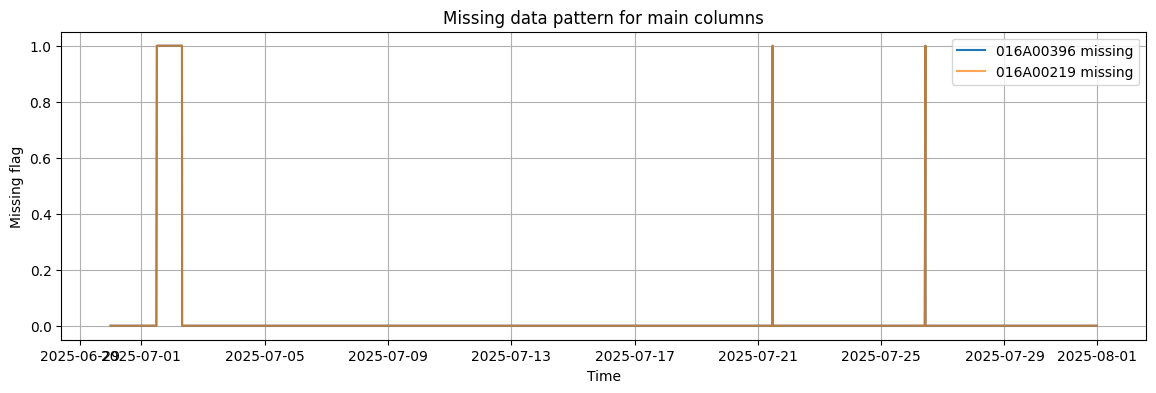

In [10]:
plt.figure(figsize=(14, 4))

plt.plot(df.index, df["016A00396"].isna().astype(int), label="016A00396 missing")
plt.plot(df.index, df["016A00219"].isna().astype(int), label="016A00219 missing", alpha=0.7)

plt.title("Missing data pattern for main columns")
plt.xlabel("Time")
plt.ylabel("Missing flag")
plt.legend()
plt.grid(True)
plt.show()

Tag mapping

In [11]:
TAG_MAPPING_PATH = DATA_PROCESSED / "tag_mapping.csv"

tag_map = pd.read_csv(TAG_MAPPING_PATH, sep=";")

tag_map.head()

,Nazwa,Opis,Symbol,Jednostka
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
